# Protocole ML commun — Projet Plantes

**But :** comparer nos 4 modèles sur **exactement les mêmes données**, pour que les écarts de score mesurent la différence entre les *algorithmes* et non entre nos pipelines.

**Ce qui est figé (ne pas modifier) :** les features, le split train/val/test, les métriques.
**Ce que tu modifies :** uniquement la **section 4**, où tu instancies ton modèle.

---

### ⚠️ AVANT DE COMMENCER — ajoute le raccourci Drive

`Projet_Plantes` est dans **« Partagés avec moi »**. Colab **ne voit pas** ce dossier tel quel.
Il faut d'abord créer un raccourci dans ton propre Drive (10 secondes, à faire **une seule fois**) :

1. Ouvre **Google Drive → Partagés avec moi**
2. **Clic droit** sur le dossier `Projet_Plantes`
3. **Organiser → Ajouter un raccourci**
4. Choisis **Mon Drive** → **Ajouter**

La cellule 1 ci-dessous vérifie que c'est bien fait.

---

### Pourquoi ce protocole

| Problème | Correction |
|---|---|
| **Fuite de données** : les augmentations d'une même feuille (`3003.JPG`, `3003_90deg.JPG`, `3003_flipLR.JPG`…) se retrouvaient de part et d'autre du split → le modèle « reconnaît » une image déjà vue, le score est gonflé | Split **groupé** : toutes les versions d'une feuille restent du même côté |
| **Chacun ses features** → impossible de savoir si l'écart vient du modèle ou de la représentation | Features **communes** (HSV + LBP, 64 dimensions) |

**Bon à savoir :** tu n'as **pas besoin des images** ni de décompresser les archives.
Tout est déjà dans les fichiers `.npz` — le chargement prend quelques secondes.

# **Etape 0 : accès à l'environnement**

In [ ]:
# ============================================================
# 0. VÉRIFICATION DE L'ACCÈS — à lancer en premier
# ============================================================
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

BASE = Path("/content/drive/MyDrive/Liora-Data_Science/Projet_Plantes")

if not BASE.exists():
    print("❌ Projet_Plantes INTROUVABLE dans MyDrive.\n")
    print("Le dossier est en 'Partagés avec moi' : Colab ne le voit pas.")
    print("Corrige en 10 secondes :")
    print("   1. Google Drive → Partagés avec moi")
    print("   2. Clic droit sur 'Projet_Plantes'")
    print("   3. Organiser → Ajouter un raccourci")
    print("   4. Choisis 'Mon Drive' → Ajouter")
    print("   5. Relance cette cellule\n")
    raise SystemExit("Raccourci Drive manquant — voir instructions ci-dessus.")

print("✅ Projet_Plantes accessible")
print("Contenu :", sorted(p.name for p in BASE.iterdir())[:10])

Mounted at /content/drive
✅ Projet_Plantes accessible
Contenu : ['Bronislaw', 'Ghislain', 'MALADIES.zip', 'Messaline', 'Modèles CNN', 'Paul el Forzli', 'README.txt', 'README2.txt', 'Rapport Analyse', 'Rapport Modélisation']


# **A . TAXONS PIXEL**

## A1. Chargement des données

In [ ]:
# ============================================================
# A1. CHOIX DE LA BASE ET CHARGEMENT DES DONNEES - TAXONS PIXEL
# ============================================================

BASE_CHOISIE = "TAXONS"          # <-- "TAXONS" ou "MALADIES"

DOSSIERS = {
#    "TAXONS":   BASE / "features" / "taxons_v2",
    "TAXONS":   BASE / "features" / "taxons_raw",
#    "MALADIES": BASE / "features" / "maladies_v2",
    "MALADIES": BASE / "features" / "maladies_raw",
}
FEAT_DIR = DOSSIERS[BASE_CHOISIE]

if not FEAT_DIR.exists():
    raise SystemExit(f"❌ Dossier introuvable : {FEAT_DIR}\n"
                     f"Préviens Ghislain — les features de {BASE_CHOISIE} "
                     f"ne sont peut-être pas encore déposées.")

fichiers = sorted(p.name for p in FEAT_DIR.iterdir())
print(f"Base    : {BASE_CHOISIE}")
print(f"Dossier : {FEAT_DIR}")
print(f"Fichiers: {fichiers}")

manquants = {"train.npz", "val.npz", "test.npz"} - set(fichiers)
if manquants:
    raise SystemExit(f"❌ Fichiers manquants : {manquants}")
print("✅ Les 3 fichiers de features sont là.")

# ============================================================
# CHARGEMENT DES DONNEES
# ============================================================

import numpy as np
from sklearn.preprocessing import LabelEncoder

tr = np.load(FEAT_DIR / "train.npz", allow_pickle=True)
va = np.load(FEAT_DIR / "val.npz",   allow_pickle=True)
te = np.load(FEAT_DIR / "test.npz",  allow_pickle=True)

X_tr,  y_tr_raw  = tr['X'], tr['y']
X_val, y_val_raw = va['X'], va['y']
X_te,  y_te_raw  = te['X'], te['y']

# Encodage des labels : fit sur le TRAIN uniquement
le = LabelEncoder().fit(y_tr_raw)
y_tr  = le.transform(y_tr_raw)
y_val = le.transform(y_val_raw)
y_te  = le.transform(y_te_raw)
n_classes = len(le.classes_)

print(f"Train : {X_tr.shape}   |   Val : {X_val.shape}   |   Test : {X_te.shape}")
print(f"{X_tr.shape[1]} features par image (histogrammes HSV + texture LBP)")
print(f"{n_classes} classes\n")
print("Classes :", list(le.classes_))


Base    : TAXONS
Dossier : /content/drive/MyDrive/Liora-Data_Science/Projet_Plantes/features/taxons_raw
Fichiers: ['test.npz', 'train.npz', 'val.npz']
✅ Les 3 fichiers de features sont là.
Train : (67377, 3072)   |   Val : (14370, 3072)   |   Test : (14418, 3072)
3072 features par image (histogrammes HSV + texture LBP)
14 classes

Classes : [np.str_('apple'), np.str_('blueberry'), np.str_('cherry_including_sour'), np.str_('grape'), np.str_('maize'), np.str_('orange'), np.str_('peach'), np.str_('pepper_bell'), np.str_('potato'), np.str_('raspberry'), np.str_('soybean'), np.str_('squash'), np.str_('strawberry'), np.str_('tomato')]


## A2. Modèle SGD Classifier

✅ Modèle entraîné : SGDClassifier
Modèle et LabelEncoder sauvegardés.
DIAGNOSTIC SURAPPRENTISSAGE — SGDClassifier
Jeu                Accuracy    F1 macro
----------------------------------------------------------
Entraînement          0.658       0.644
Validation            0.623       0.602
Test                  0.619       0.602
----------------------------------------------------------
Écart train - test : +0.039 (+3.9 points)

✅ PAS DE SURAPPRENTISSAGE SIGNIFICATIF — le modèle généralise bien
✅ Validation et test cohérents : l'évaluation est stable.


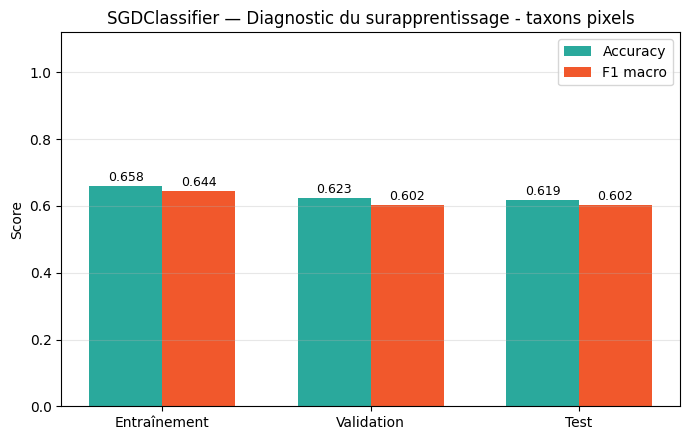

In [ ]:
# ============================================================
# A2. MODELE SGD CLASSIFIER - ENTRAINEMENT ET SURAPPRENTISSAGE - TAXONS PIXEL
# ============================================================
from sklearn.utils.class_weight import compute_sample_weight

sw = compute_sample_weight('balanced', y_tr)   # compense le déséquilibre des classes

# ---------- PAUL : SGD Classifier ----------
from sklearn.linear_model import SGDClassifier
model = SGDClassifier(
    loss='hinge',
    alpha=1e-4,
    max_iter=1000,
    tol=1e-2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1)
model.fit(X_tr, y_tr)

print("✅ Modèle entraîné :", type(model).__name__)

# ============================================================
# SAUVEGARDE DU MODELE POUR STREAMLIT
# ============================================================

import joblib
from pathlib import Path

DOSSIER_STR = Path("/content/drive/MyDrive/Liora-Data_Science/Projet_Plantes/Paul el Forzli/Streamlit")
DOSSIER_STR.mkdir(parents=True, exist_ok=True)

joblib.dump(model,DOSSIER_STR / "sgd_classifier.joblib")
joblib.dump(le, DOSSIER_STR / "label_encoder.joblib")

print("Modèle et LabelEncoder sauvegardés.")

# ============================================================
# DIAGNOSTIC DU SURAPPRENTISSAGE
# ============================================================
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Prédictions sur les 3 jeux
pred_tr  = model.predict(X_tr)
pred_val = model.predict(X_val)
pred_te  = model.predict(X_te)

scores = {
    "Entraînement": (accuracy_score(y_tr,  pred_tr),
                     f1_score(y_tr,  pred_tr,  average='macro')),
    "Validation":   (accuracy_score(y_val, pred_val),
                     f1_score(y_val, pred_val, average='macro')),
    "Test":         (accuracy_score(y_te,  pred_te),
                     f1_score(y_te,  pred_te,  average='macro')),
}

print("=" * 58)
print(f"DIAGNOSTIC SURAPPRENTISSAGE — {type(model).__name__}")
print("=" * 58)
print(f"{'Jeu':<15}{'Accuracy':>12}{'F1 macro':>12}")
print("-" * 58)
for nom, (a, f) in scores.items():
    print(f"{nom:<15}{a:>12.3f}{f:>12.3f}")
print("-" * 58)

# --- L'écart train / test est le signal clé ---
ecart = scores["Entraînement"][0] - scores["Test"][0]
print(f"Écart train - test : {ecart:+.3f} ({ecart*100:+.1f} points)\n")

if ecart > 0.15:
    verdict = "❌ SURAPPRENTISSAGE MARQUÉ — le modèle mémorise au lieu de généraliser"
elif ecart > 0.07:
    verdict = "⚠️  SURAPPRENTISSAGE MODÉRÉ — écart notable, à surveiller"
else:
    verdict = "✅ PAS DE SURAPPRENTISSAGE SIGNIFICATIF — le modèle généralise bien"
print(verdict)

# --- Cohérence validation / test (contrôle de fiabilité de l'évaluation) ---
diff_vt = abs(scores["Validation"][0] - scores["Test"][0])
if diff_vt < 0.03:
    print("✅ Validation et test cohérents : l'évaluation est stable.")
else:
    print(f"⚠️  Écart validation/test de {diff_vt:.3f} : évaluation moins stable.")

# --- Graphique ---
jeux = list(scores.keys())
accs = [scores[j][0] for j in jeux]
f1s  = [scores[j][1] for j in jeux]
x = np.arange(len(jeux)); w = 0.35

plt.figure(figsize=(7, 4.5))
plt.bar(x - w/2, accs, w, label='Accuracy',  color='#2AA99C')
plt.bar(x + w/2, f1s,  w, label='F1 macro',  color='#F1582C')
for i, (a, f) in enumerate(zip(accs, f1s)):
    plt.text(i - w/2, a + 0.015, f"{a:.3f}", ha='center', fontsize=9)
    plt.text(i + w/2, f + 0.015, f"{f:.3f}", ha='center', fontsize=9)
plt.xticks(x, jeux)
plt.ylim(0, 1.12)
plt.ylabel("Score")
plt.title(f"{type(model).__name__} — Diagnostic du surapprentissage - taxons pixels")
plt.legend(); plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Liora-Data_Science/Projet_Plantes/Paul el Forzli/Streamlit/SGDClassifier_overfitting.png")
plt.show();

In [ ]:
modele_test = joblib.load(DOSSIER_STR / "sgd_classifier.joblib")
encodeur_test = joblib.load(DOSSIER_STR / "label_encoder.joblib")

prediction_numerique = modele_test.predict(X_te[:1])
prediction_classe = encodeur_test.inverse_transform(prediction_numerique)

print("Numéro prédit :", prediction_numerique[0])
print("Classe prédite :", prediction_classe[0])

Numéro prédit : 0
Classe prédite : apple


## ABonus. Optimisation des hyperparamètres

Utilisation d'un GridSearch pour détecter les hyperparamètres qui fournissent les meilleurs résultats sur le train de la base taxons.

Cette cellule met du temps à tourner (ne **pas** la relancer à chaque fois). Les meilleurs hyperparamètres en l'occurrence sont :
alpha = 0.0001,
tol = 0.001.

In [ ]:
# ============================================================
# BONUS : OPTIMISATION DES HYPERPARAMETRES - TAXONS PIXEL
# ============================================================

from sklearn.model_selection import GridSearchCV

model = model
parameters = {"loss" : ['hinge'], "alpha" : [1e-4, 1e-3, 1e-2, 1e-1], "max_iter" : [1000], "tol" : [1e-2, 1e-3], "class_weight" : ['balanced']}

clf_grid = GridSearchCV(estimator = model, param_grid = parameters, cv = 5, scoring = 'accuracy', n_jobs = -1)
clf_grid.fit(X_tr, y_tr)
print("Les meilleurs paramètres :", clf_grid.best_params_)
print("Le score d'accuracy avec ces paramètres :", clf_grid.best_score_)


KeyboardInterrupt: 

## A3. Évaluation commune

Mêmes métriques pour tout le monde : **accuracy**, **F1-score macro** (le chiffre clé vu le
déséquilibre des classes) et **matrice de confusion**. Ne modifiez pas cette cellule.

BASE     : TAXONS   (14 classes)
MODÈLE   : SGDClassifier
--------------------------------------------------------------
Accuracy   : 0.631
F1 macro   : 0.594   <- chiffre clé (classes déséquilibrées)
F1 pondéré : 0.630

                       precision    recall  f1-score   support

                apple       0.62      0.23      0.34      1422
            blueberry       0.45      0.61      0.52       341
cherry_including_sour       0.82      0.29      0.42       659
                grape       0.91      0.69      0.79      1347
                maize       0.86      0.89      0.88      1318
               orange       0.77      0.90      0.83       842
                peach       0.47      0.59      0.53       671
          pepper_bell       0.27      0.55      0.36       738
               potato       0.47      0.56      0.51      1060
            raspberry       0.53      0.49      0.51       358
              soybean       0.89      0.66      0.76       750
               squash 

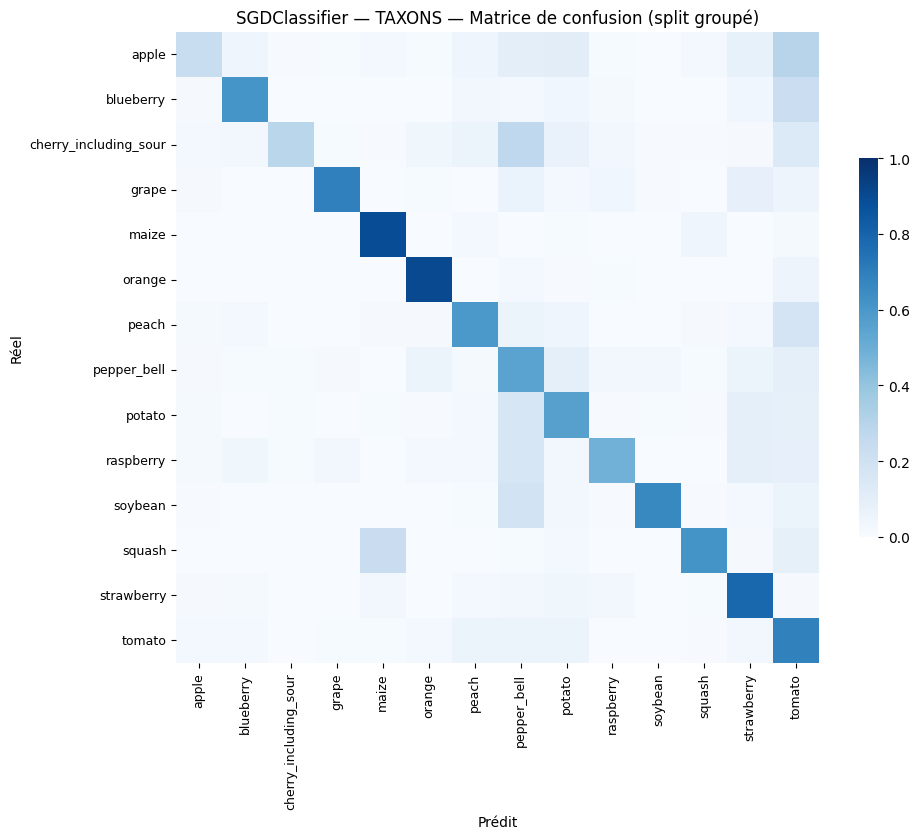

In [ ]:
# ============================================================
# A3. ÉVALUATION COMMUNE - TAXONS PIXEL
# ============================================================
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(X_te)
acc = accuracy_score(y_te, y_pred)
f1m = f1_score(y_te, y_pred, average='macro')
f1w = f1_score(y_te, y_pred, average='weighted')

print("=" * 62)
print(f"BASE     : {BASE_CHOISIE}   ({n_classes} classes)")
print(f"MODÈLE   : {type(model).__name__}")
print("-" * 62)
print(f"Accuracy   : {acc:.3f}")
print(f"F1 macro   : {f1m:.3f}   <- chiffre clé (classes déséquilibrées)")
print(f"F1 pondéré : {f1w:.3f}")
print("=" * 62)
print()
print(classification_report(y_te, y_pred, target_names=le.classes_))

# --- Matrice de confusion ---
taille = 10 if n_classes <= 20 else 16
cm = confusion_matrix(y_te, y_pred, normalize='true')
plt.figure(figsize=(taille, taille * 0.85))
sns.heatmap(cm, xticklabels=le.classes_, yticklabels=le.classes_,
            cmap='Blues', vmin=0, vmax=1, square=(n_classes > 20),
            cbar_kws={'shrink': 0.6})
plt.xlabel("Prédit"); plt.ylabel("Réel")
plt.title(f"{type(model).__name__} — {BASE_CHOISIE} — Matrice de confusion (split groupé)")
plt.xticks(rotation=90, fontsize=7 if n_classes > 20 else 9)
plt.yticks(rotation=0,  fontsize=7 if n_classes > 20 else 9)
plt.tight_layout(); plt.show()

## A4. Conclusions

Avec les hyperparamètres fixés grâce au GridSearch à alpha = 1e-4 et tol = 1e-3, le modèle obtient un accuracy rate de près de 70%.

Plus précisément, l'**accuracy** sur l'ensemble d'entraînement est de **67,8%** ; 63,4% sur l'ensemble de validation et 63,1% sur l'ensemble de test. Il y a donc un **surapprentissage**  léger de 4.7 points. Le score F1 s'élève à 64.6% sur les données d'entraînement et à 59.4% sur les données de test.

Certaines classes sont difficiles à prédire avec justesse, comme les pommes régulièrement prises pour des tomates. De manière générale, les poivres et les tomates sont sur-prédites par le modèle.

# **B. MALADIES PIXEL**

## B1. Chargement des données

In [ ]:
# ============================================================
# B1. CHOIX DE LA BASE ET CHARGEMENT DES DONNEES
# ============================================================

BASE_CHOISIE = "MALADIES"          # <-- "TAXONS" ou "MALADIES"

DOSSIERS = {
    "TAXONS":   BASE / "features" / "taxons_raw",
    "MALADIES": BASE / "features" / "maladies_raw",
}
FEAT_DIR = DOSSIERS[BASE_CHOISIE]

if not FEAT_DIR.exists():
    raise SystemExit(f"❌ Dossier introuvable : {FEAT_DIR}\n"
                     f"Préviens Ghislain — les features de {BASE_CHOISIE} "
                     f"ne sont peut-être pas encore déposées.")

fichiers = sorted(p.name for p in FEAT_DIR.iterdir())
print(f"Base    : {BASE_CHOISIE}")
print(f"Dossier : {FEAT_DIR}")
print(f"Fichiers: {fichiers}")

manquants = {"train.npz", "val.npz", "test.npz"} - set(fichiers)
if manquants:
    raise SystemExit(f"❌ Fichiers manquants : {manquants}")
print("✅ Les 3 fichiers de features sont là.")

# ============================================================
# 3. CHARGEMENT DES DONNEES
# ============================================================
import numpy as np
from sklearn.preprocessing import LabelEncoder

tr = np.load(FEAT_DIR / "train.npz", allow_pickle=True)
va = np.load(FEAT_DIR / "val.npz",   allow_pickle=True)
te = np.load(FEAT_DIR / "test.npz",  allow_pickle=True)

X_tr,  y_tr_raw  = tr['X'], tr['y']
X_val, y_val_raw = va['X'], va['y']
X_te,  y_te_raw  = te['X'], te['y']

# Encodage des labels : fit sur le TRAIN uniquement
le = LabelEncoder().fit(y_tr_raw)
y_tr  = le.transform(y_tr_raw)
y_val = le.transform(y_val_raw)
y_te  = le.transform(y_te_raw)
n_classes = len(le.classes_)

print(f"Train : {X_tr.shape}   |   Val : {X_val.shape}   |   Test : {X_te.shape}")
print(f"{X_tr.shape[1]} features par image (histogrammes HSV + texture LBP)")
print(f"{n_classes} classes\n")
print("Classes :", list(le.classes_))

Base    : MALADIES
Dossier : /content/drive/MyDrive/Liora-Data_Science/Projet_Plantes/features/maladies_raw
Fichiers: ['test.npz', 'train.npz', 'val.npz']
✅ Les 3 fichiers de features sont là.
Train : (67339, 3072)   |   Val : (14402, 3072)   |   Test : (14424, 3072)
3072 features par image (histogrammes HSV + texture LBP)
38 classes

Classes : [np.str_('apple___apple_scab'), np.str_('apple___black_rot'), np.str_('apple___cedar_apple_rust'), np.str_('apple___healthy'), np.str_('blueberry___healthy'), np.str_('cherry_including_sour___healthy'), np.str_('cherry_including_sour___powdery_mildew'), np.str_('grape___black_rot'), np.str_('grape___esca_black_measles'), np.str_('grape___healthy'), np.str_('grape___leaf_blight_isariopsis_leaf_spot'), np.str_('maize___cercospora_leaf_spot_gray_leaf_spot'), np.str_('maize___common_rust'), np.str_('maize___healthy'), np.str_('maize___northern_leaf_blight'), np.str_('orange___haunglongbing_citrus_greening'), np.str_('peach___bacterial_spot'), np.str

## B2. Modèle SGD Classifier

✅ Modèle entraîné : SGDClassifier
DIAGNOSTIC SURAPPRENTISSAGE — SGDClassifier
Jeu                Accuracy    F1 macro
----------------------------------------------------------
Entraînement          0.655       0.655
Validation            0.551       0.543
Test                  0.552       0.546
----------------------------------------------------------
Écart train - test : +0.103 (+10.3 points)

⚠️  SURAPPRENTISSAGE MODÉRÉ — écart notable, à surveiller
✅ Validation et test cohérents : l'évaluation est stable.


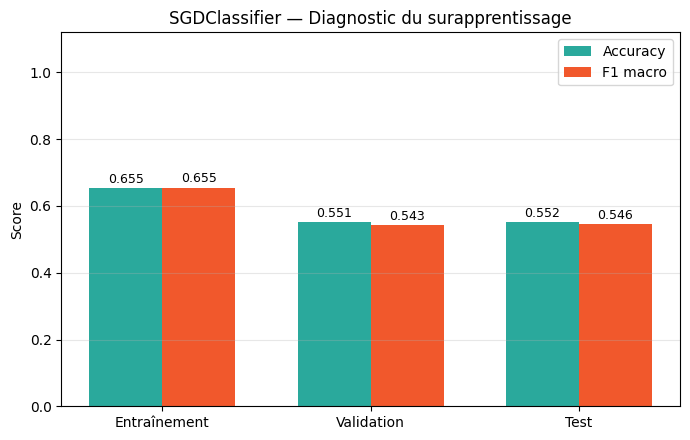

In [ ]:
# ============================================================
# B2. SGD CLASSIFIER ET SURAPRENTISSAGE
# ============================================================
from sklearn.utils.class_weight import compute_sample_weight

sw = compute_sample_weight('balanced', y_tr)   # compense le déséquilibre des classes

# ---------- PAUL : SGD Classifier ----------
from sklearn.linear_model import SGDClassifier
model = SGDClassifier(
    loss='hinge', alpha=1e-4, max_iter=1000, tol=1e-3,
    class_weight='balanced', random_state=42, n_jobs=-1)
model.fit(X_tr, y_tr)

print("✅ Modèle entraîné :", type(model).__name__)


# ============================================================
# DIAGNOSTIC DU SURAPPRENTISSAGE (ne pas modifier)
# ============================================================
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Prédictions sur les 3 jeux
pred_tr  = model.predict(X_tr)
pred_val = model.predict(X_val)
pred_te  = model.predict(X_te)

scores = {
    "Entraînement": (accuracy_score(y_tr,  pred_tr),
                     f1_score(y_tr,  pred_tr,  average='macro')),
    "Validation":   (accuracy_score(y_val, pred_val),
                     f1_score(y_val, pred_val, average='macro')),
    "Test":         (accuracy_score(y_te,  pred_te),
                     f1_score(y_te,  pred_te,  average='macro')),
}

print("=" * 58)
print(f"DIAGNOSTIC SURAPPRENTISSAGE — {type(model).__name__}")
print("=" * 58)
print(f"{'Jeu':<15}{'Accuracy':>12}{'F1 macro':>12}")
print("-" * 58)
for nom, (a, f) in scores.items():
    print(f"{nom:<15}{a:>12.3f}{f:>12.3f}")
print("-" * 58)

# --- L'écart train / test est le signal clé ---
ecart = scores["Entraînement"][0] - scores["Test"][0]
print(f"Écart train - test : {ecart:+.3f} ({ecart*100:+.1f} points)\n")

if ecart > 0.15:
    verdict = "❌ SURAPPRENTISSAGE MARQUÉ — le modèle mémorise au lieu de généraliser"
elif ecart > 0.07:
    verdict = "⚠️  SURAPPRENTISSAGE MODÉRÉ — écart notable, à surveiller"
else:
    verdict = "✅ PAS DE SURAPPRENTISSAGE SIGNIFICATIF — le modèle généralise bien"
print(verdict)

# --- Cohérence validation / test (contrôle de fiabilité de l'évaluation) ---
diff_vt = abs(scores["Validation"][0] - scores["Test"][0])
if diff_vt < 0.03:
    print("✅ Validation et test cohérents : l'évaluation est stable.")
else:
    print(f"⚠️  Écart validation/test de {diff_vt:.3f} : évaluation moins stable.")

# --- Graphique ---
jeux = list(scores.keys())
accs = [scores[j][0] for j in jeux]
f1s  = [scores[j][1] for j in jeux]
x = np.arange(len(jeux)); w = 0.35

plt.figure(figsize=(7, 4.5))
plt.bar(x - w/2, accs, w, label='Accuracy',  color='#2AA99C')
plt.bar(x + w/2, f1s,  w, label='F1 macro',  color='#F1582C')
for i, (a, f) in enumerate(zip(accs, f1s)):
    plt.text(i - w/2, a + 0.015, f"{a:.3f}", ha='center', fontsize=9)
    plt.text(i + w/2, f + 0.015, f"{f:.3f}", ha='center', fontsize=9)
plt.xticks(x, jeux)
plt.ylim(0, 1.12)
plt.ylabel("Score")
plt.title(f"{type(model).__name__} — Diagnostic du surapprentissage")
plt.legend(); plt.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## B3. Evaluation commune

BASE     : MALADIES   (38 classes)
MODÈLE   : SGDClassifier
--------------------------------------------------------------
Accuracy   : 0.552
F1 macro   : 0.546   <- chiffre clé (classes déséquilibrées)
F1 pondéré : 0.567

                                               precision    recall  f1-score   support

                           apple___apple_scab       0.22      0.77      0.34       358
                            apple___black_rot       0.62      0.33      0.43       360
                     apple___cedar_apple_rust       0.29      0.45      0.35       321
                              apple___healthy       0.70      0.18      0.29       380
                          blueberry___healthy       0.69      0.43      0.53       346
              cherry_including_sour___healthy       0.73      0.61      0.67       354
       cherry_including_sour___powdery_mildew       0.76      0.51      0.61       305
                            grape___black_rot       0.88      0.55      0.67    

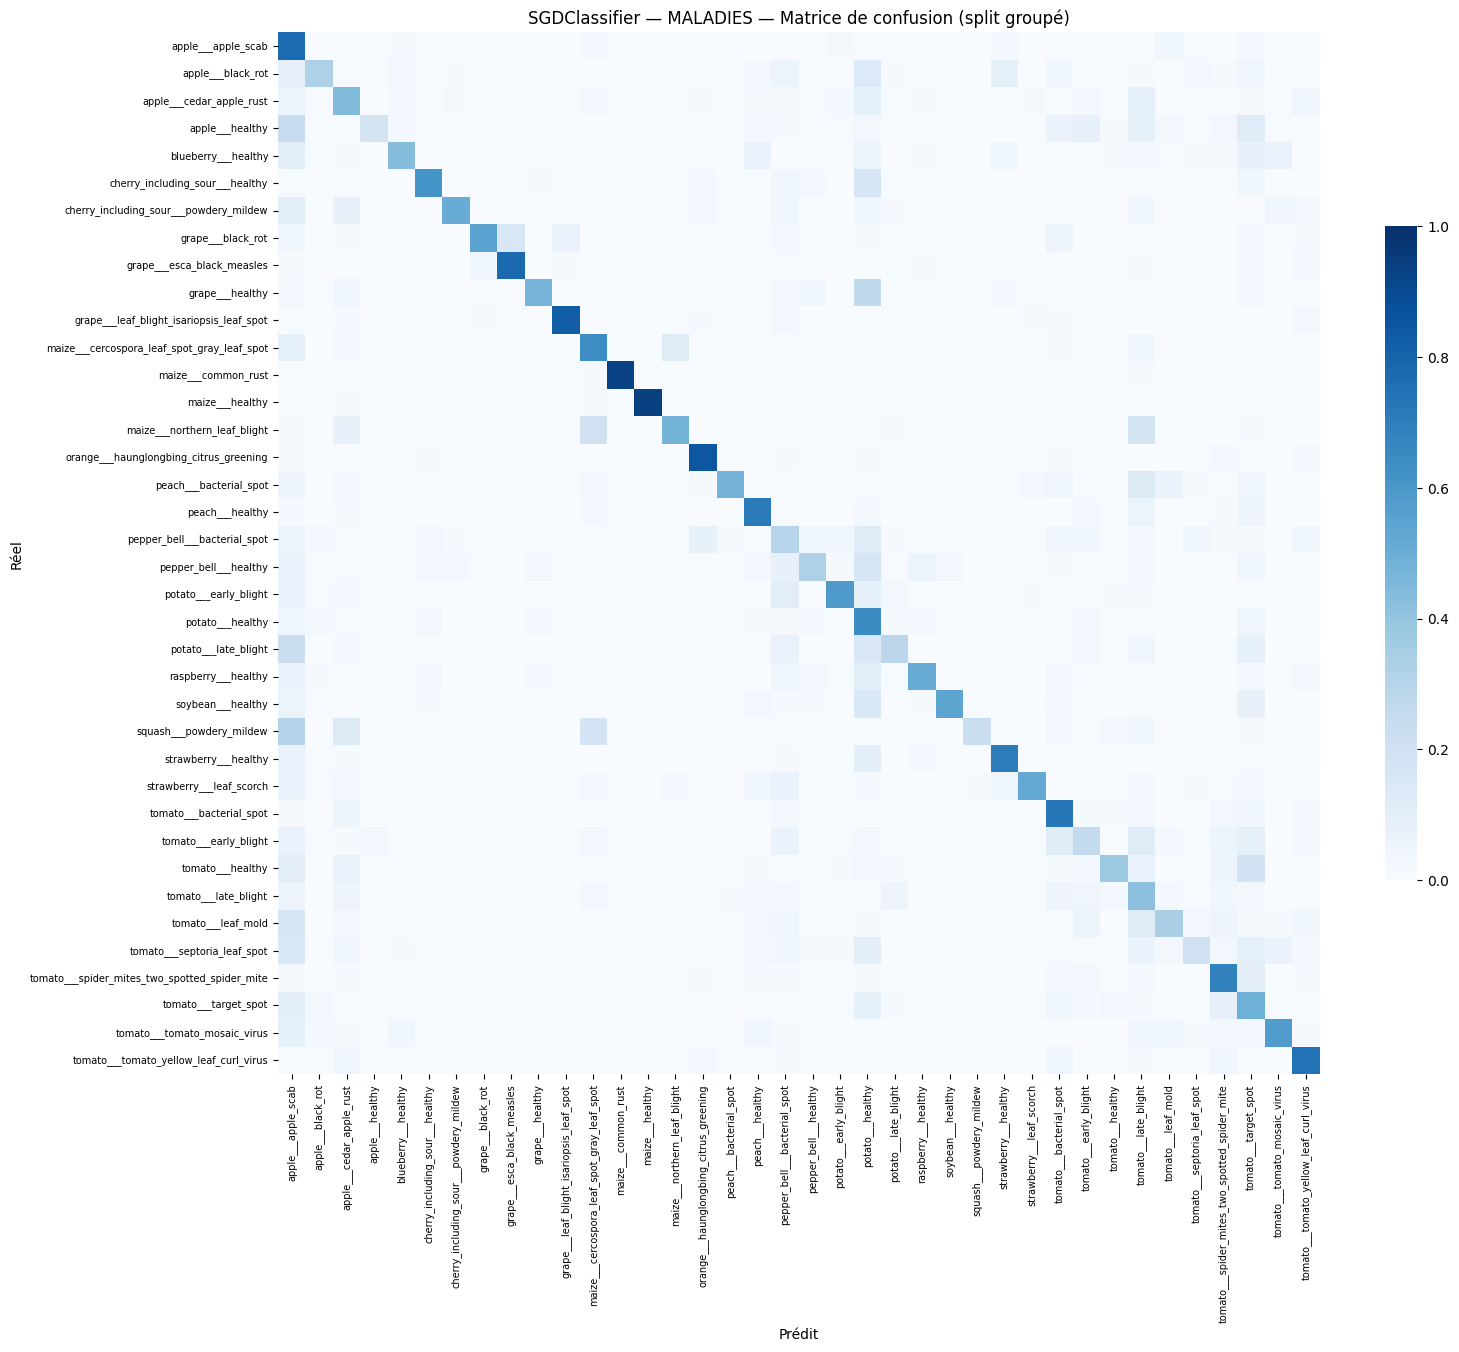

In [ ]:
# ============================================================
# B3. ÉVALUATION COMMUNE (ne pas modifier)
# ============================================================
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(X_te)
acc = accuracy_score(y_te, y_pred)
f1m = f1_score(y_te, y_pred, average='macro')
f1w = f1_score(y_te, y_pred, average='weighted')

print("=" * 62)
print(f"BASE     : {BASE_CHOISIE}   ({n_classes} classes)")
print(f"MODÈLE   : {type(model).__name__}")
print("-" * 62)
print(f"Accuracy   : {acc:.3f}")
print(f"F1 macro   : {f1m:.3f}   <- chiffre clé (classes déséquilibrées)")
print(f"F1 pondéré : {f1w:.3f}")
print("=" * 62)
print()
print(classification_report(y_te, y_pred, target_names=le.classes_))

# --- Matrice de confusion ---
taille = 10 if n_classes <= 20 else 16
cm = confusion_matrix(y_te, y_pred, normalize='true')
plt.figure(figsize=(taille, taille * 0.85))
sns.heatmap(cm, xticklabels=le.classes_, yticklabels=le.classes_,
            cmap='Blues', vmin=0, vmax=1, square=(n_classes > 20),
            cbar_kws={'shrink': 0.6})
plt.xlabel("Prédit"); plt.ylabel("Réel")
plt.title(f"{type(model).__name__} — {BASE_CHOISIE} — Matrice de confusion (split groupé)")
plt.xticks(rotation=90, fontsize=7 if n_classes > 20 else 9)
plt.yticks(rotation=0,  fontsize=7 if n_classes > 20 else 9)
plt.tight_layout(); plt.show()

## B4. Conclusions

Avec les hyperparamètres fixés grâce au GridSearch à alpha = 1e-4 et tol = 1e-3, le modèle obtient un accuracy rate de près de 66%, soit légèrement moins que précédemment, ce qui est normal au vu de la démultiplicité des classes.

Plus précisément, l'**accuracy** sur l'ensemble d'entraînement est de **66,0%** ; 66,1% sur l'ensemble de test. Il n'y a donc aucun **surapprentissage**. Le score F1 s'élève à 63.4% sur les données d'entraînement et à 63.3% sur les données de test.

# **C. TAXONS HOG**

## C1. Chargement des données

In [ ]:
# ============================================================
# C1. CHOIX DE LA BASE ET CHARGEMENT DES DONNEES - TAXONS HOG
# ============================================================

BASE_CHOISIE = "TAXONS"          # <-- "TAXONS" ou "MALADIES"

DOSSIERS = {
#    "TAXONS":   BASE / "features" / "taxons_v2",
    "TAXONS":   BASE / "features" / "taxons_hog",
#    "MALADIES": BASE / "features" / "maladies_v2",
    "MALADIES": BASE / "features" / "maladies_hog",
}
FEAT_DIR = DOSSIERS[BASE_CHOISIE]

if not FEAT_DIR.exists():
    raise SystemExit(f"❌ Dossier introuvable : {FEAT_DIR}\n"
                     f"Préviens Ghislain — les features de {BASE_CHOISIE} "
                     f"ne sont peut-être pas encore déposées.")

fichiers = sorted(p.name for p in FEAT_DIR.iterdir())
print(f"Base    : {BASE_CHOISIE}")
print(f"Dossier : {FEAT_DIR}")
print(f"Fichiers: {fichiers}")

manquants = {"train.npz", "val.npz", "test.npz"} - set(fichiers)
if manquants:
    raise SystemExit(f"❌ Fichiers manquants : {manquants}")
print("✅ Les 3 fichiers de features sont là.")

# ============================================================
# CHARGEMENT DES DONNEES
# ============================================================

import numpy as np
from sklearn.preprocessing import LabelEncoder

tr = np.load(FEAT_DIR / "train.npz", allow_pickle=True)
va = np.load(FEAT_DIR / "val.npz",   allow_pickle=True)
te = np.load(FEAT_DIR / "test.npz",  allow_pickle=True)

X_tr,  y_tr_raw  = tr['X'], tr['y']
X_val, y_val_raw = va['X'], va['y']
X_te,  y_te_raw  = te['X'], te['y']

# Encodage des labels : fit sur le TRAIN uniquement
le = LabelEncoder().fit(y_tr_raw)
y_tr  = le.transform(y_tr_raw)
y_val = le.transform(y_val_raw)
y_te  = le.transform(y_te_raw)
n_classes = len(le.classes_)

print(f"Train : {X_tr.shape}   |   Val : {X_val.shape}   |   Test : {X_te.shape}")
print(f"{X_tr.shape[1]} features par image (histogrammes HSV + texture LBP)")
print(f"{n_classes} classes\n")
print("Classes :", list(le.classes_))


Base    : TAXONS
Dossier : /content/drive/MyDrive/Liora-Data_Science/Projet_Plantes/features/taxons_hog
Fichiers: ['test.npz', 'train.npz', 'val.npz']
✅ Les 3 fichiers de features sont là.
Train : (67377, 1764)   |   Val : (14370, 1764)   |   Test : (14418, 1764)
1764 features par image (histogrammes HSV + texture LBP)
14 classes

Classes : [np.str_('apple'), np.str_('blueberry'), np.str_('cherry_including_sour'), np.str_('grape'), np.str_('maize'), np.str_('orange'), np.str_('peach'), np.str_('pepper_bell'), np.str_('potato'), np.str_('raspberry'), np.str_('soybean'), np.str_('squash'), np.str_('strawberry'), np.str_('tomato')]


## C2. Modèle SGD Classifier

✅ Modèle entraîné : SGDClassifier
DIAGNOSTIC SURAPPRENTISSAGE — SGDClassifier
Jeu                Accuracy    F1 macro
----------------------------------------------------------
Entraînement          0.704       0.664
Validation            0.689       0.643
Test                  0.680       0.635
----------------------------------------------------------
Écart train - test : +0.023 (+2.3 points)

✅ PAS DE SURAPPRENTISSAGE SIGNIFICATIF — le modèle généralise bien
✅ Validation et test cohérents : l'évaluation est stable.


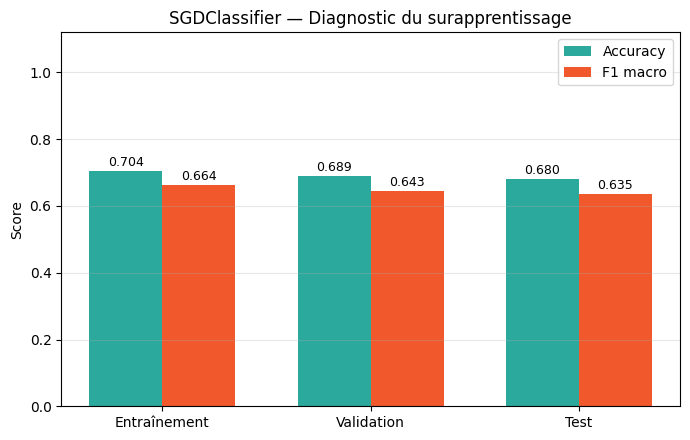

In [ ]:
# ============================================================
# C2. SGD CLASSIFIER ET SURAPRENTISSAGE
# ============================================================
from sklearn.utils.class_weight import compute_sample_weight

sw = compute_sample_weight('balanced', y_tr)   # compense le déséquilibre des classes

# ---------- PAUL : SGD Classifier ----------
from sklearn.linear_model import SGDClassifier
model = SGDClassifier(
    loss='hinge', alpha=1e-4, max_iter=1000, tol=1e-3,
    class_weight='balanced', random_state=42, n_jobs=-1)
model.fit(X_tr, y_tr)

print("✅ Modèle entraîné :", type(model).__name__)


# ============================================================
# DIAGNOSTIC DU SURAPPRENTISSAGE (ne pas modifier)
# ============================================================
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Prédictions sur les 3 jeux
pred_tr  = model.predict(X_tr)
pred_val = model.predict(X_val)
pred_te  = model.predict(X_te)

scores = {
    "Entraînement": (accuracy_score(y_tr,  pred_tr),
                     f1_score(y_tr,  pred_tr,  average='macro')),
    "Validation":   (accuracy_score(y_val, pred_val),
                     f1_score(y_val, pred_val, average='macro')),
    "Test":         (accuracy_score(y_te,  pred_te),
                     f1_score(y_te,  pred_te,  average='macro')),
}

print("=" * 58)
print(f"DIAGNOSTIC SURAPPRENTISSAGE — {type(model).__name__}")
print("=" * 58)
print(f"{'Jeu':<15}{'Accuracy':>12}{'F1 macro':>12}")
print("-" * 58)
for nom, (a, f) in scores.items():
    print(f"{nom:<15}{a:>12.3f}{f:>12.3f}")
print("-" * 58)

# --- L'écart train / test est le signal clé ---
ecart = scores["Entraînement"][0] - scores["Test"][0]
print(f"Écart train - test : {ecart:+.3f} ({ecart*100:+.1f} points)\n")

if ecart > 0.15:
    verdict = "❌ SURAPPRENTISSAGE MARQUÉ — le modèle mémorise au lieu de généraliser"
elif ecart > 0.07:
    verdict = "⚠️  SURAPPRENTISSAGE MODÉRÉ — écart notable, à surveiller"
else:
    verdict = "✅ PAS DE SURAPPRENTISSAGE SIGNIFICATIF — le modèle généralise bien"
print(verdict)

# --- Cohérence validation / test (contrôle de fiabilité de l'évaluation) ---
diff_vt = abs(scores["Validation"][0] - scores["Test"][0])
if diff_vt < 0.03:
    print("✅ Validation et test cohérents : l'évaluation est stable.")
else:
    print(f"⚠️  Écart validation/test de {diff_vt:.3f} : évaluation moins stable.")

# --- Graphique ---
jeux = list(scores.keys())
accs = [scores[j][0] for j in jeux]
f1s  = [scores[j][1] for j in jeux]
x = np.arange(len(jeux)); w = 0.35

plt.figure(figsize=(7, 4.5))
plt.bar(x - w/2, accs, w, label='Accuracy',  color='#2AA99C')
plt.bar(x + w/2, f1s,  w, label='F1 macro',  color='#F1582C')
for i, (a, f) in enumerate(zip(accs, f1s)):
    plt.text(i - w/2, a + 0.015, f"{a:.3f}", ha='center', fontsize=9)
    plt.text(i + w/2, f + 0.015, f"{f:.3f}", ha='center', fontsize=9)
plt.xticks(x, jeux)
plt.ylim(0, 1.12)
plt.ylabel("Score")
plt.title(f"{type(model).__name__} — Diagnostic du surapprentissage")
plt.legend(); plt.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## C3. Evaluation commune

BASE     : TAXONS   (14 classes)
MODÈLE   : SGDClassifier
--------------------------------------------------------------
Accuracy   : 0.680
F1 macro   : 0.635   <- chiffre clé (classes déséquilibrées)
F1 pondéré : 0.675

                       precision    recall  f1-score   support

                apple       0.81      0.19      0.31      1422
            blueberry       0.22      0.66      0.33       341
cherry_including_sour       0.53      0.71      0.61       659
                grape       0.83      0.91      0.87      1347
                maize       0.86      0.88      0.87      1318
               orange       0.92      0.90      0.91       842
                peach       0.62      0.52      0.56       671
          pepper_bell       0.64      0.54      0.58       738
               potato       0.43      0.88      0.58      1060
            raspberry       0.51      0.54      0.52       358
              soybean       0.82      0.69      0.75       750
               squash 

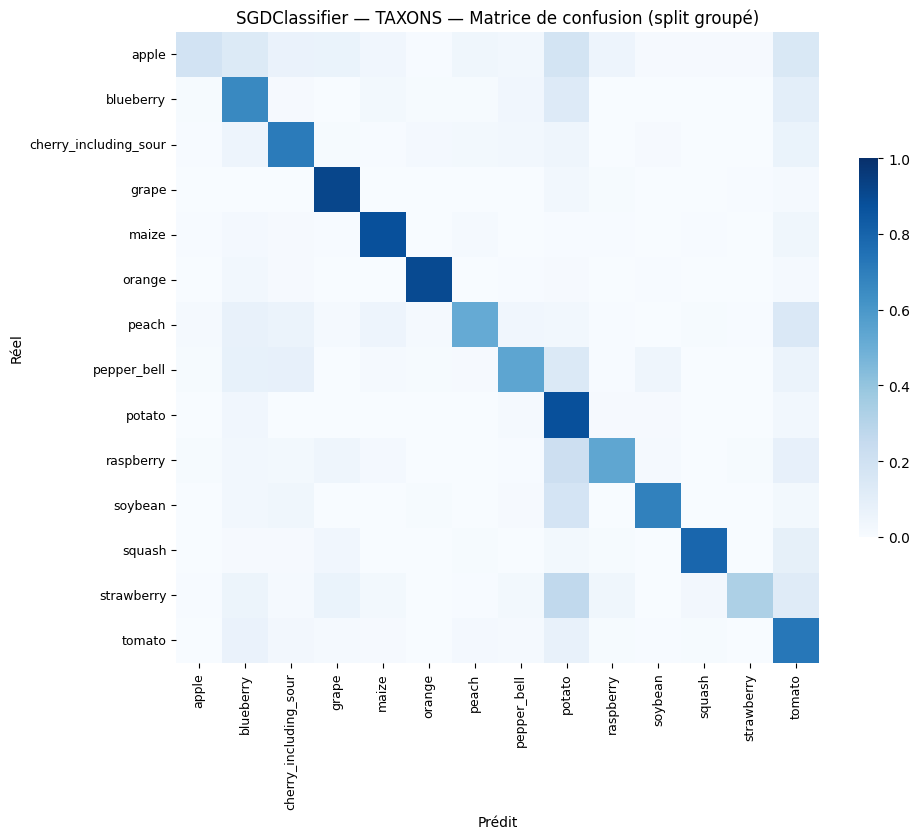

In [ ]:
# ============================================================
# C3. ÉVALUATION COMMUNE (ne pas modifier)
# ============================================================
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(X_te)
acc = accuracy_score(y_te, y_pred)
f1m = f1_score(y_te, y_pred, average='macro')
f1w = f1_score(y_te, y_pred, average='weighted')

print("=" * 62)
print(f"BASE     : {BASE_CHOISIE}   ({n_classes} classes)")
print(f"MODÈLE   : {type(model).__name__}")
print("-" * 62)
print(f"Accuracy   : {acc:.3f}")
print(f"F1 macro   : {f1m:.3f}   <- chiffre clé (classes déséquilibrées)")
print(f"F1 pondéré : {f1w:.3f}")
print("=" * 62)
print()
print(classification_report(y_te, y_pred, target_names=le.classes_))

# --- Matrice de confusion ---
taille = 10 if n_classes <= 20 else 16
cm = confusion_matrix(y_te, y_pred, normalize='true')
plt.figure(figsize=(taille, taille * 0.85))
sns.heatmap(cm, xticklabels=le.classes_, yticklabels=le.classes_,
            cmap='Blues', vmin=0, vmax=1, square=(n_classes > 20),
            cbar_kws={'shrink': 0.6})
plt.xlabel("Prédit"); plt.ylabel("Réel")
plt.title(f"{type(model).__name__} — {BASE_CHOISIE} — Matrice de confusion (split groupé)")
plt.xticks(rotation=90, fontsize=7 if n_classes > 20 else 9)
plt.yticks(rotation=0,  fontsize=7 if n_classes > 20 else 9)
plt.tight_layout(); plt.show()

## C4. Conclusions

Avec les hyperparamètres fixés grâce au GridSearch sur le train taxons à alpha = 1e-4 et tol = 1e-3, le modèle obtient un accuracy rate de près de 70%.

Plus précisément, l'**accuracy** sur l'ensemble d'entraînement est de **70,4%** ; 68,9% sur l'ensemble de validation et 68,0% sur l'ensemble de test. Il y a donc un **surapprentissage** très léger, **non significatif**, de 2.3 points. Le score F1 s'élève à 66.4% sur les données d'entraînement et à 63.5% sur les données de test.

Certaines classes sont difficiles à prédire avec justesse, comme les pommes régulièrement prises pour des patates ou des tomates. De manière générale, les patates et les tomates sont sur-prédites par le modèle.

# **D. MALADIES HOG**

## D1. Chargement des données

In [ ]:
# ============================================================
# D1. CHOIX DE LA BASE ET CHARGEMENT DES DONNEES - MALADIES HOG
# ============================================================

BASE_CHOISIE = "MALADIES"          # <-- "TAXONS" ou "MALADIES"

DOSSIERS = {
#    "TAXONS":   BASE / "features" / "taxons_v2",
    "TAXONS":   BASE / "features" / "taxons_hog",
#    "MALADIES": BASE / "features" / "maladies_v2",
    "MALADIES": BASE / "features" / "maladies_hog",
}
FEAT_DIR = DOSSIERS[BASE_CHOISIE]

if not FEAT_DIR.exists():
    raise SystemExit(f"❌ Dossier introuvable : {FEAT_DIR}\n"
                     f"Préviens Ghislain — les features de {BASE_CHOISIE} "
                     f"ne sont peut-être pas encore déposées.")

fichiers = sorted(p.name for p in FEAT_DIR.iterdir())
print(f"Base    : {BASE_CHOISIE}")
print(f"Dossier : {FEAT_DIR}")
print(f"Fichiers: {fichiers}")

manquants = {"train.npz", "val.npz", "test.npz"} - set(fichiers)
if manquants:
    raise SystemExit(f"❌ Fichiers manquants : {manquants}")
print("✅ Les 3 fichiers de features sont là.")

# ============================================================
# CHARGEMENT DES DONNEES
# ============================================================

import numpy as np
from sklearn.preprocessing import LabelEncoder

tr = np.load(FEAT_DIR / "train.npz", allow_pickle=True)
va = np.load(FEAT_DIR / "val.npz",   allow_pickle=True)
te = np.load(FEAT_DIR / "test.npz",  allow_pickle=True)

X_tr,  y_tr_raw  = tr['X'], tr['y']
X_val, y_val_raw = va['X'], va['y']
X_te,  y_te_raw  = te['X'], te['y']

# Encodage des labels : fit sur le TRAIN uniquement
le = LabelEncoder().fit(y_tr_raw)
y_tr  = le.transform(y_tr_raw)
y_val = le.transform(y_val_raw)
y_te  = le.transform(y_te_raw)
n_classes = len(le.classes_)

print(f"Train : {X_tr.shape}   |   Val : {X_val.shape}   |   Test : {X_te.shape}")
print(f"{X_tr.shape[1]} features par image (histogrammes HSV + texture LBP)")
print(f"{n_classes} classes\n")
print("Classes :", list(le.classes_))


Base    : MALADIES
Dossier : /content/drive/MyDrive/Liora-Data_Science/Projet_Plantes/features/maladies_hog
Fichiers: ['test.npz', 'train.npz', 'val.npz']
✅ Les 3 fichiers de features sont là.
Train : (67339, 1764)   |   Val : (14402, 1764)   |   Test : (14424, 1764)
1764 features par image (histogrammes HSV + texture LBP)
38 classes

Classes : [np.str_('apple___apple_scab'), np.str_('apple___black_rot'), np.str_('apple___cedar_apple_rust'), np.str_('apple___healthy'), np.str_('blueberry___healthy'), np.str_('cherry_including_sour___healthy'), np.str_('cherry_including_sour___powdery_mildew'), np.str_('grape___black_rot'), np.str_('grape___esca_black_measles'), np.str_('grape___healthy'), np.str_('grape___leaf_blight_isariopsis_leaf_spot'), np.str_('maize___cercospora_leaf_spot_gray_leaf_spot'), np.str_('maize___common_rust'), np.str_('maize___healthy'), np.str_('maize___northern_leaf_blight'), np.str_('orange___haunglongbing_citrus_greening'), np.str_('peach___bacterial_spot'), np.str

## D2. Modèle SGD Classifier

✅ Modèle entraîné : SGDClassifier
DIAGNOSTIC SURAPPRENTISSAGE — SGDClassifier
Jeu                Accuracy    F1 macro
----------------------------------------------------------
Entraînement          0.650       0.628
Validation            0.597       0.568
Test                  0.598       0.568
----------------------------------------------------------
Écart train - test : +0.052 (+5.2 points)

✅ PAS DE SURAPPRENTISSAGE SIGNIFICATIF — le modèle généralise bien
✅ Validation et test cohérents : l'évaluation est stable.


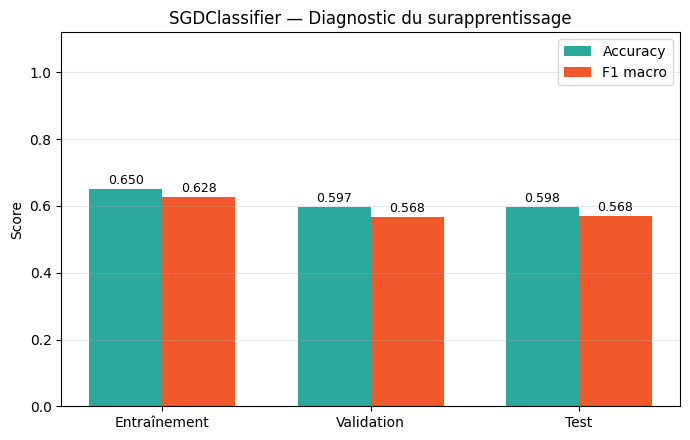

In [ ]:
# ============================================================
# D2. SGD CLASSIFIER ET SURAPRENTISSAGE
# ============================================================
from sklearn.utils.class_weight import compute_sample_weight

sw = compute_sample_weight('balanced', y_tr)   # compense le déséquilibre des classes

# ---------- PAUL : SGD Classifier ----------
from sklearn.linear_model import SGDClassifier
model = SGDClassifier(
    loss='hinge', alpha=1e-4, max_iter=1000, tol=1e-3,
    class_weight='balanced', random_state=42, n_jobs=-1)
model.fit(X_tr, y_tr)

print("✅ Modèle entraîné :", type(model).__name__)


# ============================================================
# DIAGNOSTIC DU SURAPPRENTISSAGE (ne pas modifier)
# ============================================================
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Prédictions sur les 3 jeux
pred_tr  = model.predict(X_tr)
pred_val = model.predict(X_val)
pred_te  = model.predict(X_te)

scores = {
    "Entraînement": (accuracy_score(y_tr,  pred_tr),
                     f1_score(y_tr,  pred_tr,  average='macro')),
    "Validation":   (accuracy_score(y_val, pred_val),
                     f1_score(y_val, pred_val, average='macro')),
    "Test":         (accuracy_score(y_te,  pred_te),
                     f1_score(y_te,  pred_te,  average='macro')),
}

print("=" * 58)
print(f"DIAGNOSTIC SURAPPRENTISSAGE — {type(model).__name__}")
print("=" * 58)
print(f"{'Jeu':<15}{'Accuracy':>12}{'F1 macro':>12}")
print("-" * 58)
for nom, (a, f) in scores.items():
    print(f"{nom:<15}{a:>12.3f}{f:>12.3f}")
print("-" * 58)

# --- L'écart train / test est le signal clé ---
ecart = scores["Entraînement"][0] - scores["Test"][0]
print(f"Écart train - test : {ecart:+.3f} ({ecart*100:+.1f} points)\n")

if ecart > 0.15:
    verdict = "❌ SURAPPRENTISSAGE MARQUÉ — le modèle mémorise au lieu de généraliser"
elif ecart > 0.07:
    verdict = "⚠️  SURAPPRENTISSAGE MODÉRÉ — écart notable, à surveiller"
else:
    verdict = "✅ PAS DE SURAPPRENTISSAGE SIGNIFICATIF — le modèle généralise bien"
print(verdict)

# --- Cohérence validation / test (contrôle de fiabilité de l'évaluation) ---
diff_vt = abs(scores["Validation"][0] - scores["Test"][0])
if diff_vt < 0.03:
    print("✅ Validation et test cohérents : l'évaluation est stable.")
else:
    print(f"⚠️  Écart validation/test de {diff_vt:.3f} : évaluation moins stable.")

# --- Graphique ---
jeux = list(scores.keys())
accs = [scores[j][0] for j in jeux]
f1s  = [scores[j][1] for j in jeux]
x = np.arange(len(jeux)); w = 0.35

plt.figure(figsize=(7, 4.5))
plt.bar(x - w/2, accs, w, label='Accuracy',  color='#2AA99C')
plt.bar(x + w/2, f1s,  w, label='F1 macro',  color='#F1582C')
for i, (a, f) in enumerate(zip(accs, f1s)):
    plt.text(i - w/2, a + 0.015, f"{a:.3f}", ha='center', fontsize=9)
    plt.text(i + w/2, f + 0.015, f"{f:.3f}", ha='center', fontsize=9)
plt.xticks(x, jeux)
plt.ylim(0, 1.12)
plt.ylabel("Score")
plt.title(f"{type(model).__name__} — Diagnostic du surapprentissage")
plt.legend(); plt.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## D3. Evaluation commune

BASE     : MALADIES   (38 classes)
MODÈLE   : SGDClassifier
--------------------------------------------------------------
Accuracy   : 0.598
F1 macro   : 0.568   <- chiffre clé (classes déséquilibrées)
F1 pondéré : 0.590

                                               precision    recall  f1-score   support

                           apple___apple_scab       0.40      0.46      0.43       358
                            apple___black_rot       0.57      0.61      0.59       360
                     apple___cedar_apple_rust       0.61      0.56      0.58       321
                              apple___healthy       0.72      0.16      0.26       380
                          blueberry___healthy       0.75      0.15      0.25       346
              cherry_including_sour___healthy       0.33      0.93      0.49       354
       cherry_including_sour___powdery_mildew       0.46      0.89      0.61       305
                            grape___black_rot       0.63      0.78      0.69    

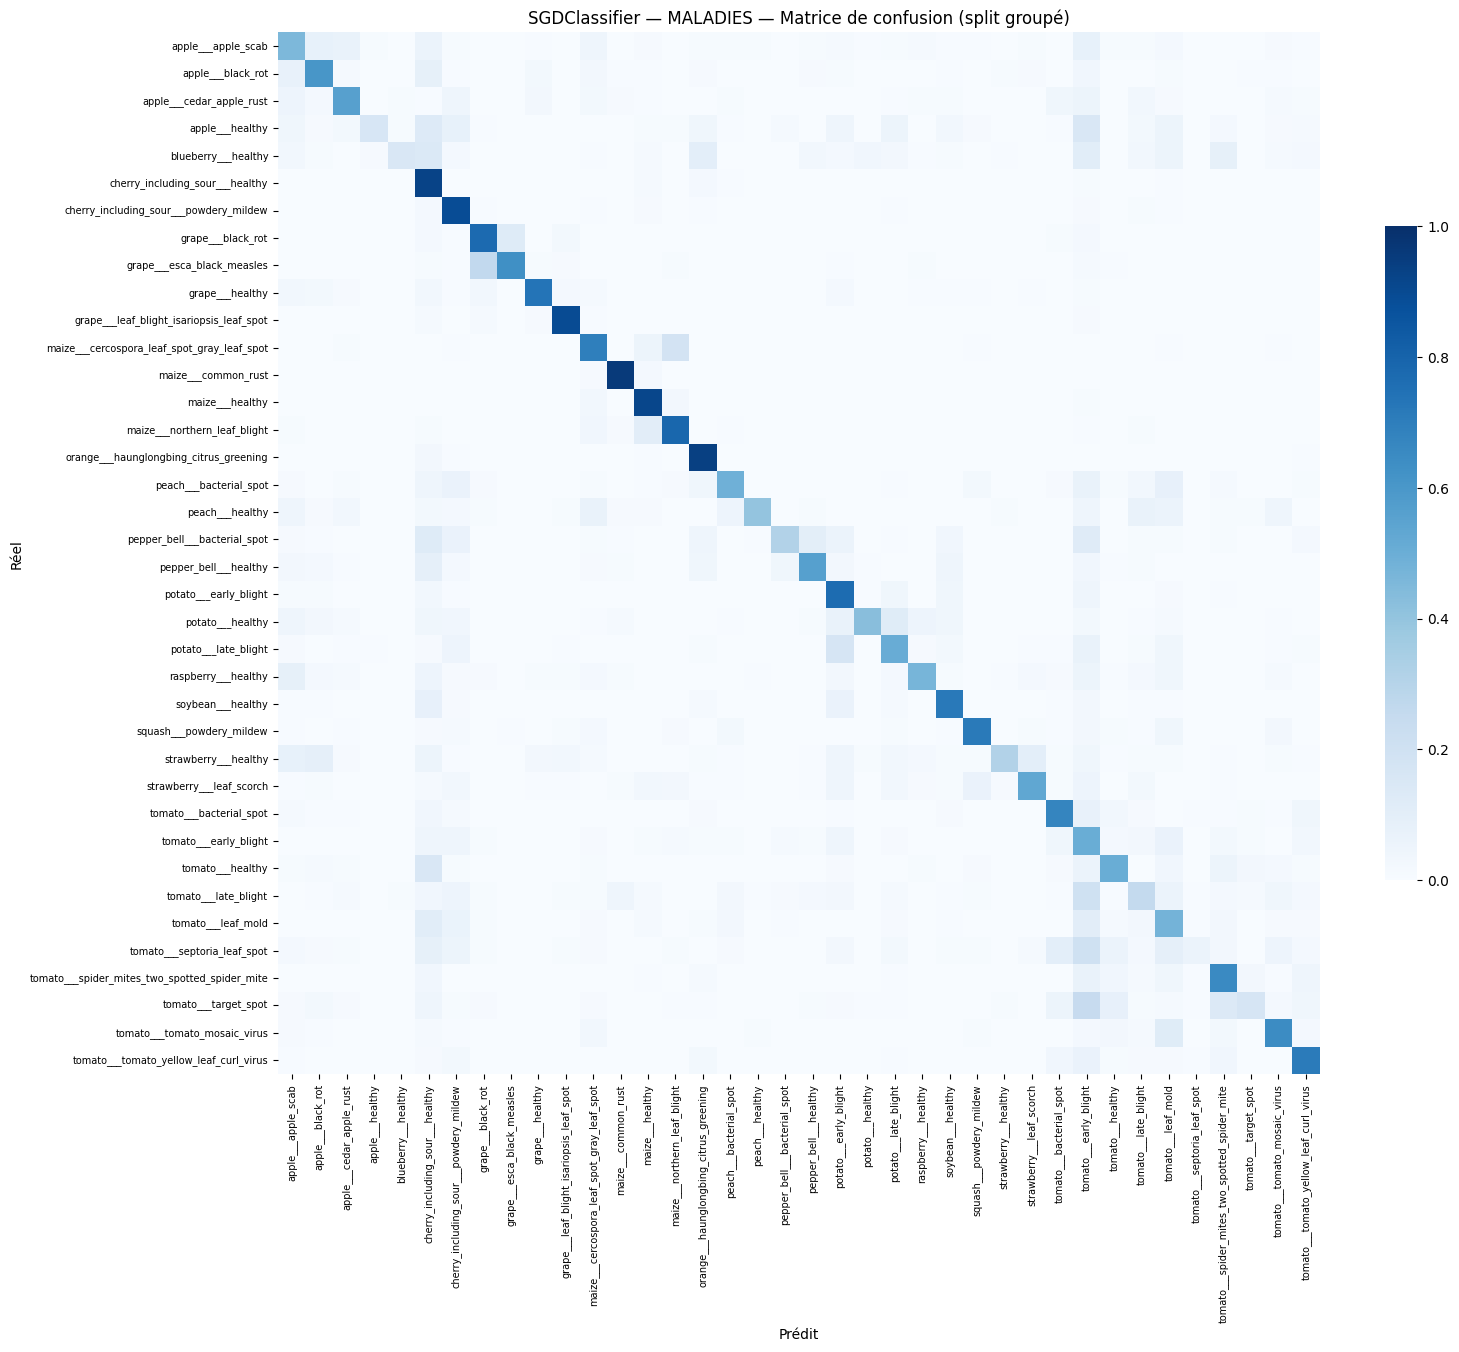

In [ ]:
# ============================================================
# D3. ÉVALUATION COMMUNE (ne pas modifier)
# ============================================================
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(X_te)
acc = accuracy_score(y_te, y_pred)
f1m = f1_score(y_te, y_pred, average='macro')
f1w = f1_score(y_te, y_pred, average='weighted')

print("=" * 62)
print(f"BASE     : {BASE_CHOISIE}   ({n_classes} classes)")
print(f"MODÈLE   : {type(model).__name__}")
print("-" * 62)
print(f"Accuracy   : {acc:.3f}")
print(f"F1 macro   : {f1m:.3f}   <- chiffre clé (classes déséquilibrées)")
print(f"F1 pondéré : {f1w:.3f}")
print("=" * 62)
print()
print(classification_report(y_te, y_pred, target_names=le.classes_))

# --- Matrice de confusion ---
taille = 10 if n_classes <= 20 else 16
cm = confusion_matrix(y_te, y_pred, normalize='true')
plt.figure(figsize=(taille, taille * 0.85))
sns.heatmap(cm, xticklabels=le.classes_, yticklabels=le.classes_,
            cmap='Blues', vmin=0, vmax=1, square=(n_classes > 20),
            cbar_kws={'shrink': 0.6})
plt.xlabel("Prédit"); plt.ylabel("Réel")
plt.title(f"{type(model).__name__} — {BASE_CHOISIE} — Matrice de confusion (split groupé)")
plt.xticks(rotation=90, fontsize=7 if n_classes > 20 else 9)
plt.yticks(rotation=0,  fontsize=7 if n_classes > 20 else 9)
plt.tight_layout(); plt.show()

## D4. Conclusions

Avec les hyperparamètres fixés grâce au GridSearch à alpha = 1e-4 et tol = 1e-3, le modèle obtient un accuracy rate de près de 65%, soit légèrement moins que précédemment, ce qui est normal au vu de la démultiplicité des classes.

Plus précisément, l'**accuracy** sur l'ensemble d'entraînement est de **65.0%** ; 59.8% sur l'ensemble de test. Il y a un **surapprentissage** de 5 points. Le score F1 s'élève à 62.8% sur les données d'entraînement et à 56.8% sur les données de test.

# Streamlit

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 71.4 MB/s eta 0:00:00


In [ ]:
%%writefile app.py

# ============================================================
# CODE DU STREAMLIT
# ============================================================

import streamlit as st

st.title("Mon application CNN")
st.write("Streamlit fonctionne correctement !")

Writing app.py


In [ ]:
!streamlit run app.py --server.port 8501 > streamlit.log 2>&1 &

In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

In [ ]:
!./cloudflared tunnel --url http://localhost:8501

2026-07-27T16:07:21Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-07-27T16:07:21Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-07-27T16:07:25Z INF +--------------------------------------------------------------------------------------------+
2026-07-27T16:07:25Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-07-27T16:07:25Z INF |  https://ancient-administrators-schedule-pcs.trycloudf